Testing out ppseq-pytorch, following the strucutre of the songbird demo

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import ppseq
import polars as pl
import os
import numpy as np

from JR_test_scripts.escape.escape_utils import load_homing, load_hdir_cells, load_significant_cells
from behave_analysis.process.process import Process
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
from ppseq.plotting import plot_model, color_plot
from ppseq.model import PPSeq
import torch.distributions as dist
from scipy.stats import zscore

%matplotlib inline

In [2]:
"""Try to use the GPU if available, otherwise default to CPU."""
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('Could not find a GPU. Defaulting to CPU instead.')

In [ ]:
"""Load data"""
exp = JAL6_flip4_21mar
session_name = 'JAL6_flip4_21mar'
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond = 1
zscoring = False

session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
frame_by_cluster_matrix = np.load(
    os.path.join(session.base_path, session.processed_path)
    + "\\"
    + "frame_by_good_cluster_matrix.npy"
)

2025-04-30 10:33:47.873 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [ ]:
"""Load which cells are tuned
We need to identify significant cells and their tuning preference - build the template"""
sig_cells = load_significant_cells(exp, case = "either_tuned", tuning_data = tuning_data)
hdir = load_hdir_cells([exp], [session_name])
sig_cells[hdir,:] = np.full(3, False)

In [ ]:
"""Keep only the data for the condition of interest"""
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
condition = np.zeros(len(bar))
condition[bar] += 1
condition[barflip] += 1

"""Load the homing data"""
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_df['frames'].to_numpy()))))

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())

if zscoring == False:
    fcm = frame_by_cluster_matrix[(condition == cond) & h_e_bool,:]
else:
    fcm = zscore(frame_by_cluster_matrix[(condition == cond) & h_e_bool,:], axis = 0)
    fcm[fcm < 0] = 0
    fcm = fcm.astype(int)

2025-04-30 10:36:53.440 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


Make the model!!

In [10]:
bin_size_ms = 1000/40
duration_bins = int(3000/bin_size_ms)
num_neurons = fcm.shape[1]

# Set gamma priors for the amplitudes
# The amplitudes are the expected number of spikes per sequence event
alpha_a0 = 2.0              
beta_a0 = alpha_a0 / 30.   

# The background rates are the expected number of spikes per bin,
# absent any sequence events
alpha_b0 = 1.0              
beta_b0 = alpha_b0 / (bin_size_ms/1000)

torch.manual_seed(0)
model = PPSeq(num_templates=1,
              num_neurons=num_neurons,
              template_duration=duration_bins,
              alpha_a0=alpha_a0,
               beta_a0=beta_a0,
               alpha_b0=alpha_b0,
               beta_b0=beta_b0,
            #    alpha_t0=1.2,
            #    beta_t0=0.1,
              )

# Initialize to a reasonable guess of the background rates
model.base_rates = fcm.mean(axis=0)

# Initialize to a reasonable guess of a single template
model.template_scales[0] = torch.ones(num_neurons) / num_neurons
model.template_offsets[0] = dist.Uniform(0, duration_bins).sample((num_neurons,))
model.template_widths[0] = 50 / bin_size_ms * torch.ones(num_neurons)           # 50ms std

In [14]:
input_tensor = torch.from_numpy(fcm.T).float().to(device)
lps, amplitudes = model.fit(input_tensor, num_iter=100)

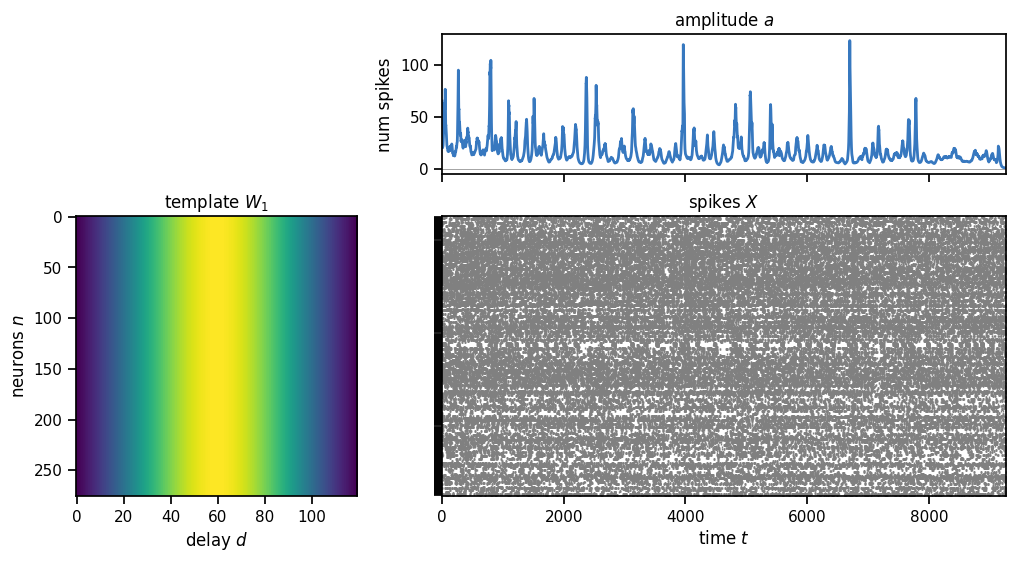

In [15]:
plot_model(model.templates.cpu(),
           amplitudes.cpu(),
           input_tensor.cpu(),
           spc=.33)
# plt.show()

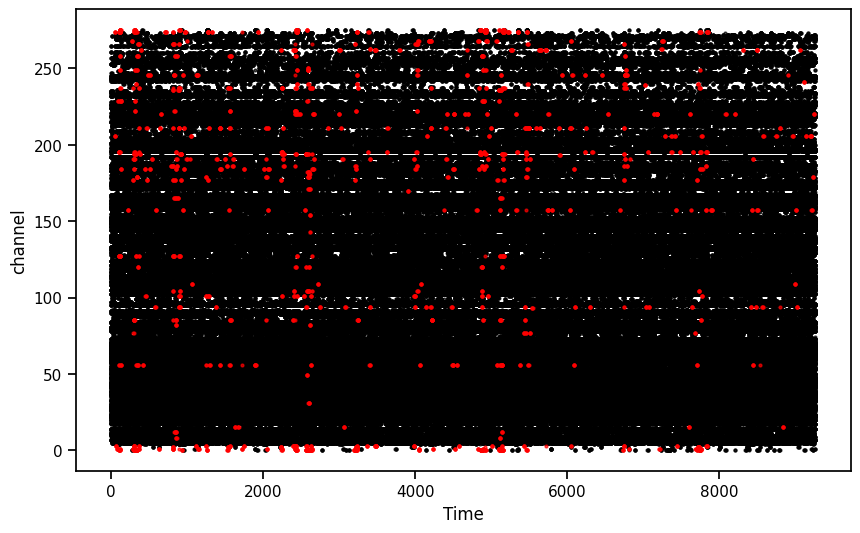

In [9]:
color_plot(input_tensor.cpu(),
           model,
           amplitudes.cpu(),
           )

In [16]:
from ppseq.plotting import sort_neurons
scale = model.template_scales.cpu()
mu = model.template_offsets.cpu()
order = sort_neurons(input_tensor.cpu(), scale, mu)

Text(0.5, 1.0, 'Activity in homing sorted by preferred tuning')

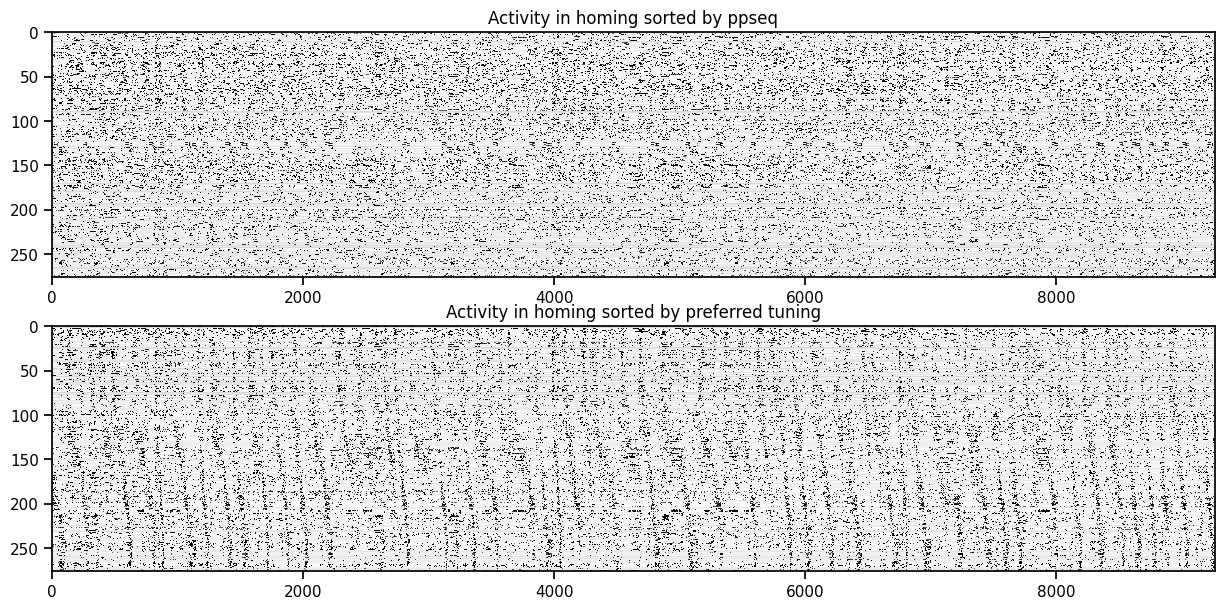

In [17]:
from scipy.stats import zscore
fig, ax = plt.subplots(2,1, figsize = (15,7))
ax[0].imshow(zscore(fcm[:,order], axis = 0).T, vmin = -.5, vmax = 1.5, aspect='auto', cmap='Greys', interpolation='none')
ax[0].set_title('Activity in homing sorted by ppseq')

homie_path = r"Z:/Jasmine_Laurence/summary_plots/tuning_curves/"
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1] # preferred %escape for neurons in each condition
template_seq = np.argsort(preferred_tuning[:,cond])

ax[1].imshow(zscore(fcm[:,template_seq], axis = 0).T, vmin = -.5, vmax = 1.5, aspect='auto', cmap='Greys', interpolation='none')
ax[1].set_title('Activity in homing sorted by preferred tuning')